In [ ]:
from google.colab import files
uploaded = files.upload()

Saving DFLabelPropagation.xlsx to DFLabelPropagation (2).xlsx


In [ ]:
"""
Módulo Label Propagation
============================

Este módulo implementa o algoritmo de propagação de rótulos aplicado a dados de
exoplanetas previamente tratados e agrupados.

Utilizando o agrupamento proporcionado pelo algoritmo de agrupamento hierárquico,
predente-se aqui, criar um conjunto de rótulos semi-supervisionados, com objetivo
de classificar todos os exoplanetas deste estudo como terrestres ou não, com
base em sua distância do centro terrestre.

Inclui:
- Aplicação do algoritmo de propagação hierárquica
- Checagem de acurácia dos rótulos propagados
- Tabela cruzada: clusters iniciais x rótulos propagados
- Plotagem dos dados no espaço PCA para visualização 2D com legendas descritivas
e porcentagem de variância

Considerações sobre o Label Propagation:
A quantidade de NT é bastante superior a de TT: Não é um erro, é reflexo da
realidade dos dados.O resultado sugere que, dentro da amostra, os exoplanetas
com características realmente próximas dos terrestres são minoria.
A maior parte dos planetas catálogados são gigantes gasosos, pq planetas
rochosos e mais próximos de suas estrelas
são mais dificeís de detectar
"""
import sys
sys.path.append("/content/drive/MyDrive/Notebooks-Colab/IC-Notebooks/src")

import numpy as np
import pandas as pd
import os
import json
import matplotlib.pyplot as plt
from sklearn.semi_supervised import LabelPropagation

In [ ]:
def carregar_info_proximidade(nome_arquivo="info_proximidade.json"):

    print("Selecione o arquivo JSON de informações de proximidade...")
    uploaded = files.upload()

    if len(uploaded) == 0:
        raise FileNotFoundError("Nenhum arquivo foi enviado.")

    nome_arquivo = list(uploaded.keys())[0]

    with open(nome_arquivo, "r") as f:
        info_proximidade = json.load(f)

    return info_proximidade

In [ ]:
def label_creation(clusters, cluster_mais_proximo, cluster_mais_distante):
    """
    4.0 Criar rótulos semi-supervisionados
    =====================================

    Cria rótulos iniciais para o algoritmo de Label Propagation,
    utilizando clusters hierárquicos e a proximidade aos parâmetros
    terrestres.

    Convenção de rótulos:
    -1 : não rotulado
     1 : TT (Tipo Terrestre)
     0 : NT (Não Terrestre)

    Parameters
    ----------
    clusters : ndarray
        Rótulos dos clusters hierárquicos
    cluster_mais_proximo : int
        Cluster mais próximo do referencial terrestre
   cluster_mais_distante : int
        Cluster mais distante do referencial terrestre
    Returns
    -------
    y_semi : ndarray
        Vetor de rótulos semi-supervisionados
    """
    print("Clusters únicos:", np.unique(clusters))

    y_semi = np.full(len(clusters), -1, dtype=int)

    # Cluster mais próximo → TT
    y_semi[clusters == cluster_mais_proximo] = 1

    # Cluster mais distante → NT
    y_semi[clusters == cluster_mais_distante] = 0

    print("\nRótulos iniciais (contagem):")
    print(pd.Series(y_semi).value_counts(sort=False))

    return y_semi

In [ ]:

def label_propagation(X, y_semi, clusters):
  """
  4.1 Label Propagation
  =========================

  Aplica o algoritmo de propagação de rótulos usando os rótulos iniciais
  criados anteriormente. Validar a acurácia sobre os rótulos já conhecidos.
  Cria uma tabela cruzada de clusters iniciais x rótulos propagados.

  Parameters
  ----------
  df : pandas.DataFrame
      Dataset (apenas para verificação de dimensões)
  y_semi : ndarray
      Vetor de rótulos semi-supervisionados
  clusters : ndarray
      Rótulos dos clusters hierárquicos

  Returns
  -------
  labels_final : ndarray
      Vetor de rótulos semi-supervisionados

  """
  lp = LabelPropagation(kernel='knn', n_neighbors=7, max_iter=1000)
  lp.fit(X, y_semi)

  labels_final = lp.transduction_

  print("\nRótulos finais (contagem):")
  print(pd.Series(labels_final).value_counts())

  mask_known = (y_semi != -1)

  if mask_known.sum() > 0:
      acc_known = (labels_final[mask_known] == y_semi[mask_known]).mean()
      print(f"\nAcurácia nos exemplos rotulados inicialmente: "
            f"{acc_known:.3f} ({mask_known.sum()} instâncias verificadas)")
  else:
      print("\nNenhum rótulo inicial disponível para validação.")

  ct = pd.crosstab(
      pd.Series(clusters, name='cluster_init'),
      pd.Series(labels_final, name='label_propagado')
  )

  print("\nCrosstab (cluster inicial x label propagado):")
  print(ct)

  return labels_final

In [ ]:
def plot_pca(X_pca, labels_final, y_semi):
    """
    4.2 PCA para visualização 2D
    ============================

    Visualização dos exoplanetas no espaço PCA 2D após Label Propagation,
    com destaque para os exemplos originalmente rotulados.

    Parameters
    ----------
    df: pandas.DataFrame
        DataFrame contendo as colunas 'PC1' e 'PC2'
    labels_final : ndarray
        Rótulos finais propagados (0 = NT, 1 = TT)
    y_semi : ndarray
        Rótulos semi-supervisionados iniciais (-1, 0, 1)
    variancia_pc1 : float
        Variância explicada da PC1 (em %)
    variancia_pc2 : float
        Variância explicada da PC2 (em %)
    """
    # Calcular variância relativa automaticamente
    var1 = np.var(X_pca["PC1"])
    var2 = np.var(X_pca["PC2"])
    total = var1 + var2

    perc1 = 100 * var1 / total
    perc2 = 100 * var2 / total

    xlabel = f"PC1 ({perc1:.1f}%)"
    ylabel = f"PC2 ({perc2:.1f}%)"

    label_names = {
        1: "TT — Tipo Terrestre",
        0: "NT — Não Terrestre"
    }

    plt.figure(figsize=(10, 7))

    for lab in np.unique(labels_final):
        mask = labels_final == lab
        count = np.sum(mask)

        plt.scatter(
            X_pca.loc[mask, "PC1"],
            X_pca.loc[mask, "PC2"],
            s=50,
            alpha=0.75,
            label=f"{label_names.get(lab, str(lab))} (n={count})"
        )

    # Destaque para exemplos inicialmente rotulados
    mask_known = y_semi != -1
    plt.scatter(
        X_pca.loc[mask_known, "PC1"],
        X_pca.loc[mask_known, "PC2"],
        facecolors="none",
        edgecolors="k",
        linewidths=0.8,
        s=80,
        label="Exemplos inicialmente rotulados"
    )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title("Distribuição dos Exoplanetas após Label Propagation (PCA 2D)")
    plt.legend(loc="best", fontsize=10)
    plt.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()

    return

In [ ]:
def export_svm_dataset(df_base,clusters,labels_lp,caminho_saida="DFsvm.xlsx"):
    """
    4.3 Exportação do dataset rotulado para SVM
    ===========================================

    Gera o DataFrame DFsvm contendo variáveis físicas,
    clusters hierárquicos e pseudo-rótulos do Label Propagation.
    """

    n = len(df_base)

    if len(clusters) != n:
        raise ValueError("Clusters e DataFrame com tamanhos diferentes")

    if len(labels_lp) != n:
        raise ValueError("Rótulos LP e DataFrame com tamanhos diferentes")

    # Definir colunas numéricas automaticamente
    colunas_excluir = ["pl_name", "cluster_hc", "PC1", "PC2"]
    colunas_numericas = [
        col for col in df_base.columns
        if col not in colunas_excluir
    ]

    colunas_saida = (
        ["pl_name"]
        + colunas_numericas
        + ["cluster_hc", "label_lp"]
    )

    DFsvm = df_base[["pl_name"] + colunas_numericas].copy()
    DFsvm["cluster_hc"] = clusters
    DFsvm["label_lp"] = labels_lp

    DFsvm = DFsvm[colunas_saida]

    DFsvm.to_excel(caminho_saida, index=False)

    print(f"\nDataset DFsvm salvo em: {caminho_saida}")
    print("\nDistribuição dos rótulos:")
    print(DFsvm["label_lp"].value_counts())

    return DFsvm

In [ ]:
def main(caminho_entrada,caminho_info_proximidade="info_proximidade.json",caminho_saida="DFsvm.xlsx"):

    df = pd.read_excel(caminho_entrada)

    print("Dataset carregado com sucesso")
    print("Shape:", df.shape)

    if "cluster_hc" not in df.columns:
        raise ValueError("Coluna 'cluster_hc' não encontrada no dataset.")

    clusters = df["cluster_hc"].values

    colunas_excluir = ["pl_name", "cluster_hc", "PC1", "PC2"]
    colunas_numericas = [
        col for col in df.columns
        if col not in colunas_excluir
    ]
    info_proximidade = carregar_info_proximidade()

    cluster_mais_proximo = info_proximidade["cluster_mais_proximo"]
    cluster_mais_distante = info_proximidade["cluster_mais_distante"]

    print("Cluster TT:", cluster_mais_proximo)
    print("Cluster NT:", cluster_mais_distante)

    y_semi = label_creation(clusters,cluster_mais_proximo,cluster_mais_distante)

    labels_final = label_propagation(df[colunas_numericas],y_semi,clusters)

    plot_pca(df[["PC1", "PC2"]],labels_final,y_semi)

    DFsvm = export_svm_dataset(df,clusters,labels_final,caminho_saida)

    print(f"\nDataset final para SVM salvo em: {caminho_saida}")

    return DFsvm, labels_final

Dataset carregado com sucesso
Shape: (2739, 9)
Selecione o arquivo JSON de informações de proximidade...


Saving info_proximidade.json to info_proximidade (2).json
Cluster TT: 2
Cluster NT: 1
Clusters únicos: [1 2 3 4]

Rótulos iniciais (contagem):
 0     397
 1     430
-1    1912
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:324: ConvergenceWarning: max_iter=1000 was reached without convergence.
  warnings.warn(



Rótulos finais (contagem):
0    2163
1     576
Name: count, dtype: int64

Acurácia nos exemplos rotulados inicialmente: 1.000 (827 instâncias verificadas)

Crosstab (cluster inicial x label propagado):
label_propagado     0    1
cluster_init              
1                 397    0
2                   0  430
3                 133   10
4                1633  136


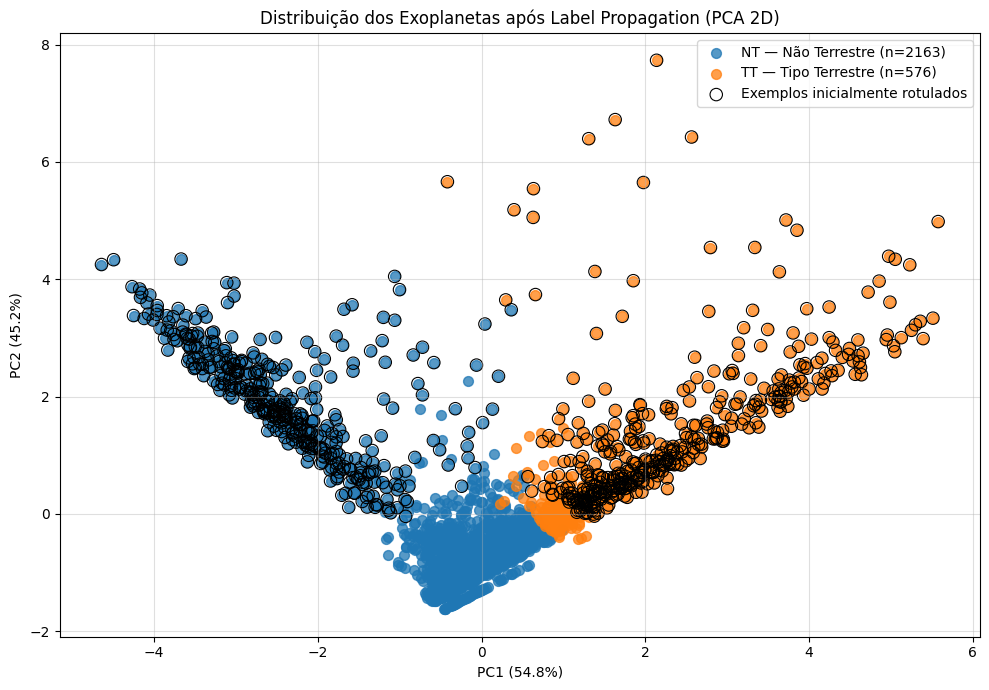


Dataset DFsvm salvo em: DFsvm.xlsx

Distribuição dos rótulos:
label_lp
0    2163
1     576
Name: count, dtype: int64

Dataset final para SVM salvo em: DFsvm.xlsx


In [ ]:
DFsvm, labels_lp = main(
    caminho_entrada="DFLabelPropagation.xlsx",
    caminho_info_proximidade="info_proximidade.json",
    caminho_saida="DFsvm.xlsx"
)